<a href="https://colab.research.google.com/github/BrendJ510/Proyectos-Escolares/blob/main/RedesNeuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#percetron

In [ ]:
lr = 1 # rango de aprendizaje learning rate
bias = 2 #values of bias
weights = [random.random(),random.random(),random.random()] #initial weights

In [ ]:
def Perceptron(input1, input2, output):
   outputP = input1*weights[0]+input2*weights[1]+bias*weights[2]
   if outputP > 0 : #activation function (here Heaviside)
      outputP = 1
   else :
      outputP = 0
   error = output - outputP
   weights[0] += error * input1 * lr
   weights[1] += error * input2 * lr
   weights[2] += error * bias * lr

In [ ]:
for i in range(50): #Tabla de verdad de v "o"
   Perceptron(1,1,1) # V & V ->V
   Perceptron(1,0,0) #V & f ->f
   Perceptron(0,1,0) # f & V ->f
   Perceptron(0,0,0) # f & f ->f

In [ ]:
x = int(input())
y= int(input())
outputP = x*weights[0]+y*weights[1]+bias*weights[2]
if outputP > 0 : #activation function (here Heaviside)
   outputP = 1
else :
    outputP = 0
print(x,'&', y, ' es ', outputP)

1
1
1 & 1  es  1


In [ ]:
df_1 = pd.read_csv('/content/mnist_train.csv',header = None)
df_1.head

<bound method NDFrame.head of        0    1    2    3    4    5    6    7    8    9    ...  775  776  777  \
0        5    0    0    0    0    0    0    0    0    0  ...    0    0    0   
1        0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
2        4    0    0    0    0    0    0    0    0    0  ...    0    0    0   
3        1    0    0    0    0    0    0    0    0    0  ...    0    0    0   
4        9    0    0    0    0    0    0    0    0    0  ...    0    0    0   
...    ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
59995    8    0    0    0    0    0    0    0    0    0  ...    0    0    0   
59996    3    0    0    0    0    0    0    0    0    0  ...    0    0    0   
59997    5    0    0    0    0    0    0    0    0    0  ...    0    0    0   
59998    6    0    0    0    0    0    0    0    0    0  ...    0    0    0   
59999    8    0    0    0    0    0    0    0    0    0  ...    0    0    0   

       778  779  780  781  782  783  784  
0        0    0    0    0    0    0    0  
1        0    0    0    0    0    0    0  
2        0    0    0    0    0    0    0  
3        0    0    0    0    0    0    0  
4        0    0    0    0    0    0    0  
...    ...  ...  ...  ...  ...  ...  ...  
59995    0    0    0    0    0    0    0  
59996    0    0    0    0    0    0    0  
59997    0    0    0    0    0    0    0  
59998    0    0    0    0    0    0    0  
59999    0    0    0    0    0    0    0  

[60000 rows x 785 columns]>

In [ ]:
df_2 = pd.read_csv('/content/mnist_test.csv',header = None)
df_2.head

<bound method NDFrame.head of       0    1    2    3    4    5    6    7    8    9    ...  775  776  777  \
0       7    0    0    0    0    0    0    0    0    0  ...    0    0    0   
1       2    0    0    0    0    0    0    0    0    0  ...    0    0    0   
2       1    0    0    0    0    0    0    0    0    0  ...    0    0    0   
3       0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
4       4    0    0    0    0    0    0    0    0    0  ...    0    0    0   
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
9995    2    0    0    0    0    0    0    0    0    0  ...    0    0    0   
9996    3    0    0    0    0    0    0    0    0    0  ...    0    0    0   
9997    4    0    0    0    0    0    0    0    0    0  ...    0    0    0   
9998    5    0    0    0    0    0    0    0    0    0  ...    0    0    0   
9999    6    0    0    0    0    0    0    0    0    0  ...    0    0    0   

      778  779  780  781  782  783  784  
0       0    0    0    0    0    0    0  
1       0    0    0    0    0    0    0  
2       0    0    0    0    0    0    0  
3       0    0    0    0    0    0    0  
4       0    0    0    0    0    0    0  
...   ...  ...  ...  ...  ...  ...  ...  
9995    0    0    0    0    0    0    0  
9996    0    0    0    0    0    0    0  
9997    0    0    0    0    0    0    0  
9998    0    0    0    0    0    0    0  
9999    0    0    0    0    0    0    0  

[10000 rows x 785 columns]>

In [ ]:
df = pd.concat([df_1,df_2])
df.head

<bound method NDFrame.head of       0    1    2    3    4    5    6    7    8    9    ...  775  776  777  \
0       5    0    0    0    0    0    0    0    0    0  ...    0    0    0   
1       0    0    0    0    0    0    0    0    0    0  ...    0    0    0   
2       4    0    0    0    0    0    0    0    0    0  ...    0    0    0   
3       1    0    0    0    0    0    0    0    0    0  ...    0    0    0   
4       9    0    0    0    0    0    0    0    0    0  ...    0    0    0   
...   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
9995    2    0    0    0    0    0    0    0    0    0  ...    0    0    0   
9996    3    0    0    0    0    0    0    0    0    0  ...    0    0    0   
9997    4    0    0    0    0    0    0    0    0    0  ...    0    0    0   
9998    5    0    0    0    0    0    0    0    0    0  ...    0    0    0   
9999    6    0    0    0    0    0    0    0    0    0  ...    0    0    0   

      778  779  780  781  782  783  784  
0       0    0    0    0    0    0    0  
1       0    0    0    0    0    0    0  
2       0    0    0    0    0    0    0  
3       0    0    0    0    0    0    0  
4       0    0    0    0    0    0    0  
...   ...  ...  ...  ...  ...  ...  ...  
9995    0    0    0    0    0    0    0  
9996    0    0    0    0    0    0    0  
9997    0    0    0    0    0    0    0  
9998    0    0    0    0    0    0    0  
9999    0    0    0    0    0    0    0  

[70000 rows x 785 columns]>

In [ ]:
X = df.iloc[ : , 1:]
Y= df[0]

In [ ]:
digit_count = Y.value_counts().reset_index()
digit_count.columns = ['digit', 'count']
fig = px.pie(digit_count, values = 'count', names = 'digit', title = 'Digit Percentage')
fig.update_traces(textposition = 'inside', textinfo = 'percent+label')
fig.update_layout(showlegend = False)
fig.show()

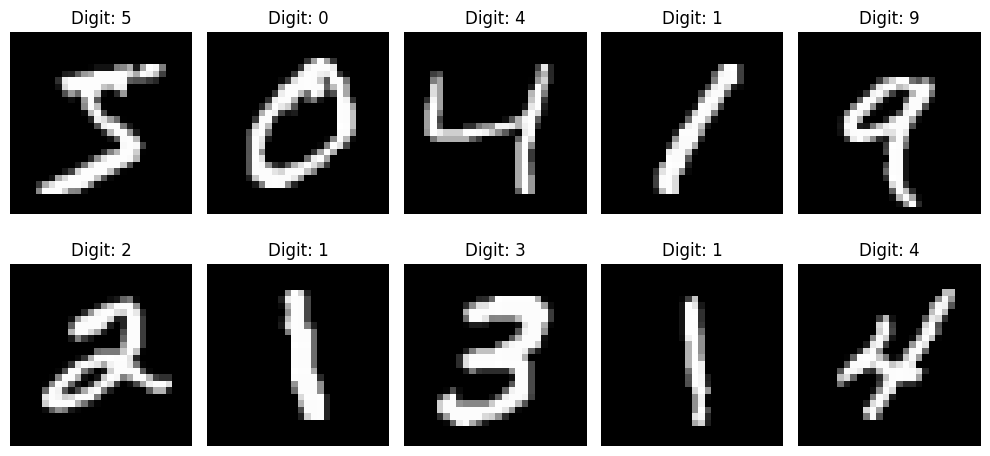

In [ ]:
fig, axs = plt.subplots(2, 5, figsize = (10, 5))
for i in range (10):
  ax = axs[i // 5, i % 5]
  ax.imshow(np.array(X.iloc[i]).reshape(28, 28), cmap = 'gray')
  ax.set_title(f'Digit: {Y[i].values[0]}')
  ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
X_norm = X /255.0
X_norm.head()

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, Y, test_size = 0.15, shuffle = True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.15, shuffle = True)

In [ ]:
y_train = to_categorical(y_train) #debe predecir un numero entero no intermedio
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

In [ ]:
model = Sequential([
    Flatten(input_shape = (784, )), #se alinea con el numero de datos, entrada
    Dense(128, activation = 'relu'), #capa densa que todo este conectado, oculta
    Dense(10, activation = 'softmax'), # digitos que tengo capa de salida, debe ser el número de clasificaciones que tenga
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

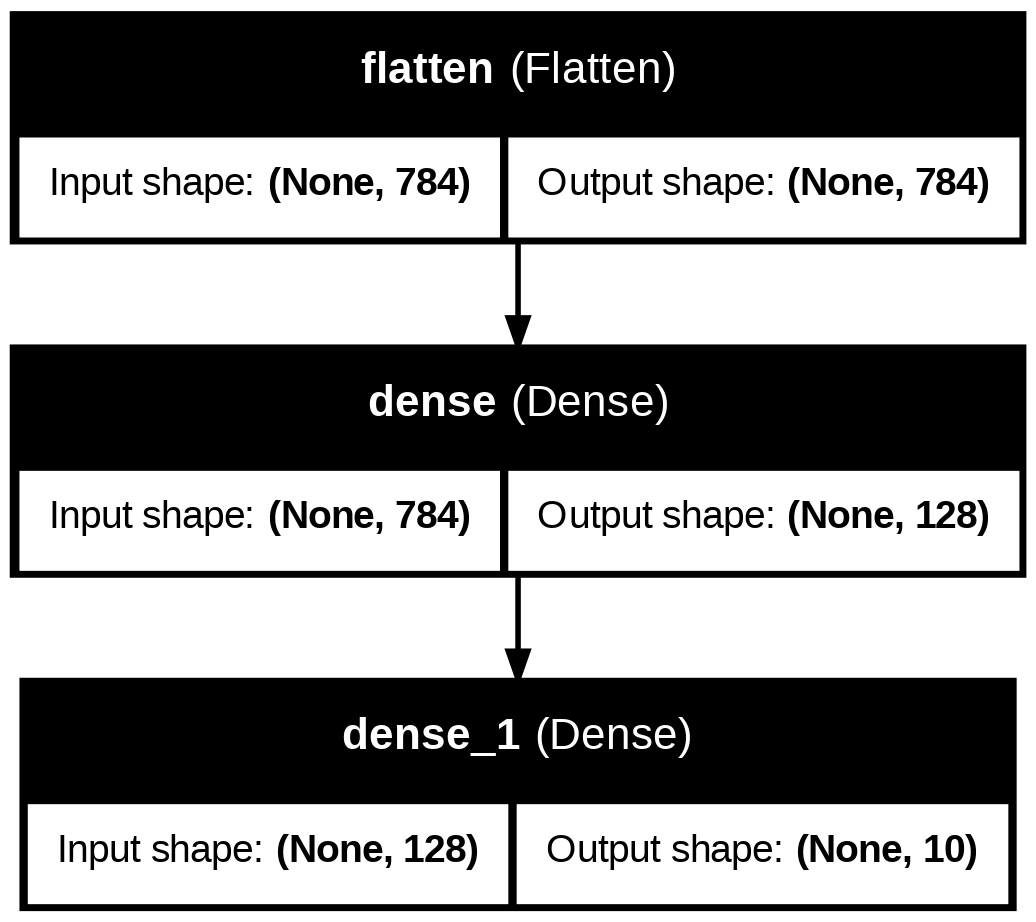

In [ ]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 50, restore_best_weights = True) #en lugar de loss es la que voy a monitoriar f1 pj, restore para que las neuronas se quede con lo mejor y no lo ultimo

In [ ]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs = 1000, batch_size = 32, #potencias de 2 en 32, entre más grande más rapido es con menos precicion
                    validation_data = (X_val, y_val), callbacks = [early_stopping]) #entrena el modelo

Epoch 1/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8753 - loss: 0.4485 - val_accuracy: 0.9473 - val_loss: 0.1741
Epoch 2/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9595 - loss: 0.1326 - val_accuracy: 0.9654 - val_loss: 0.1229
Epoch 3/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9744 - loss: 0.0866 - val_accuracy: 0.9699 - val_loss: 0.1058
Epoch 4/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9812 - loss: 0.0609 - val_accuracy: 0.9725 - val_loss: 0.1028
Epoch 5/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9856 - loss: 0.0482 - val_accuracy: 0.9746 - val_loss: 0.0915
Epoch 6/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9892 - loss: 0.0352 - val_accuracy: 0.9738 - val_loss: 0.0931
Epoch 7/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9915 - loss: 0.0278 - val_accuracy: 0.9742 - val_loss: 0.0943
Epoch 8/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9928 -

In [ ]:
score = model.evaluate(X_test, y_test)

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9757 - loss: 0.0837


In [ ]:
print(f'Accuracy: {score[1]}')
print(f'Loss: {score[0]}')

Accuracy: 0.9776190519332886
Loss: 0.07661569118499756


In [ ]:
history.history.keys()
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

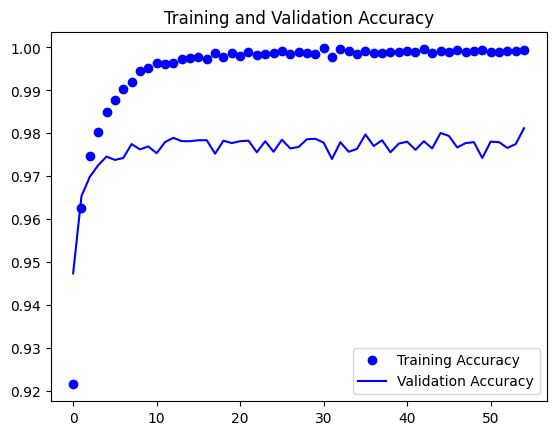

In [ ]:
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, 'bo', label = 'Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

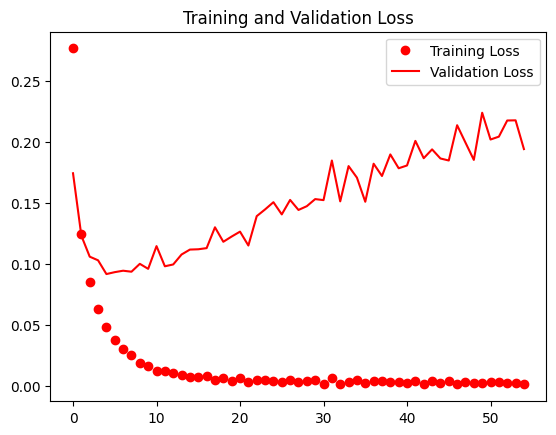

In [ ]:
plt.plot(epochs, loss, 'ro', label = 'Training Loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis = 1)
Y_true = np.argmax(y_test, axis = 1)

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Axes: >

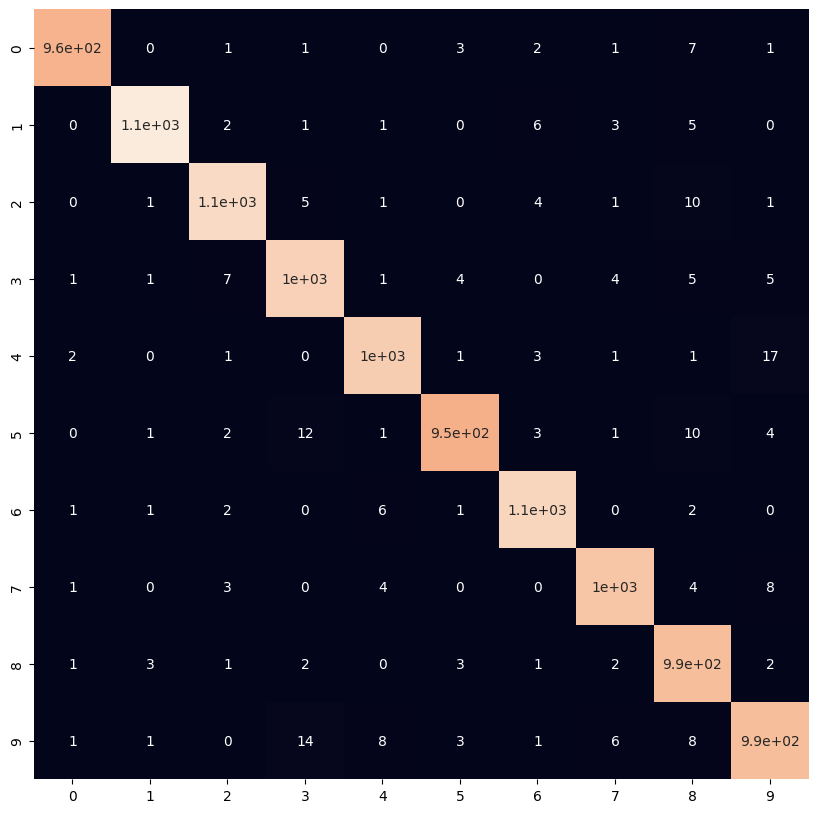

In [ ]:

cm = confusion_matrix(Y_true, y_pred)
plt.figure(figsize = (10, 10))
sns.heatmap(cm, annot = True, cbar = False)

In [ ]:
print(classification_report(Y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       977
           1       0.99      0.98      0.99      1145
           2       0.98      0.98      0.98      1100
           3       0.97      0.97      0.97      1077
           4       0.98      0.98      0.98      1063
           5       0.98      0.97      0.97       985
           6       0.98      0.99      0.98      1075
           7       0.98      0.98      0.98      1036
           8       0.95      0.99      0.97      1009
           9       0.96      0.96      0.96      1033

    accuracy                           0.98     10500
   macro avg       0.98      0.98      0.98     10500
weighted avg       0.98      0.98      0.98     10500



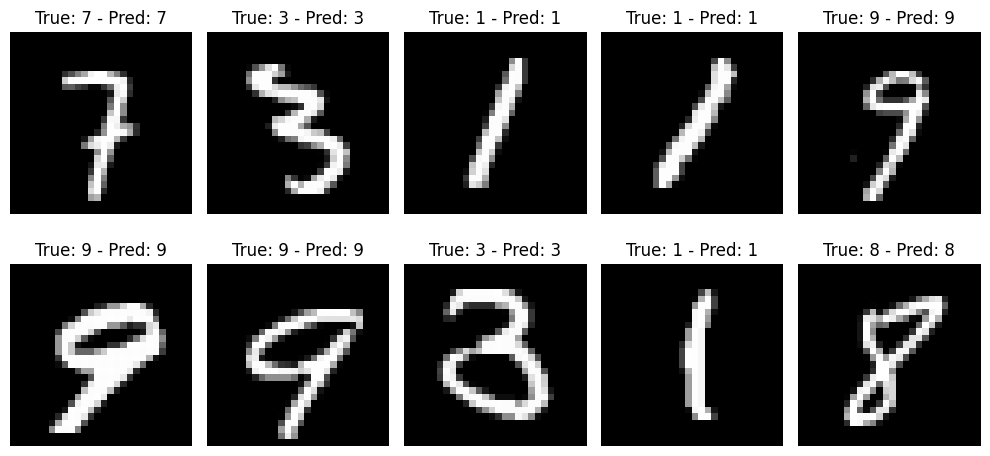

In [ ]:
fig, axs = plt.subplots(2, 5, figsize = (10, 5))
for i in range (10):
  ax = axs[i // 5, i % 5]
  ax.imshow(np.array(X_test.iloc[i]).reshape(28, 28), cmap = 'gray')
  ax.set_title(f'True: {Y_true[i]} - Pred: {y_pred[i]}')
  ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
X_norm = X_norm.values.reshape(-1, 28, 28, 1)
X_train, X_test, y_train, y_test = train_test_split(X_norm, Y, test_size = 0.15, shuffle = True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.15, shuffle = True)

y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

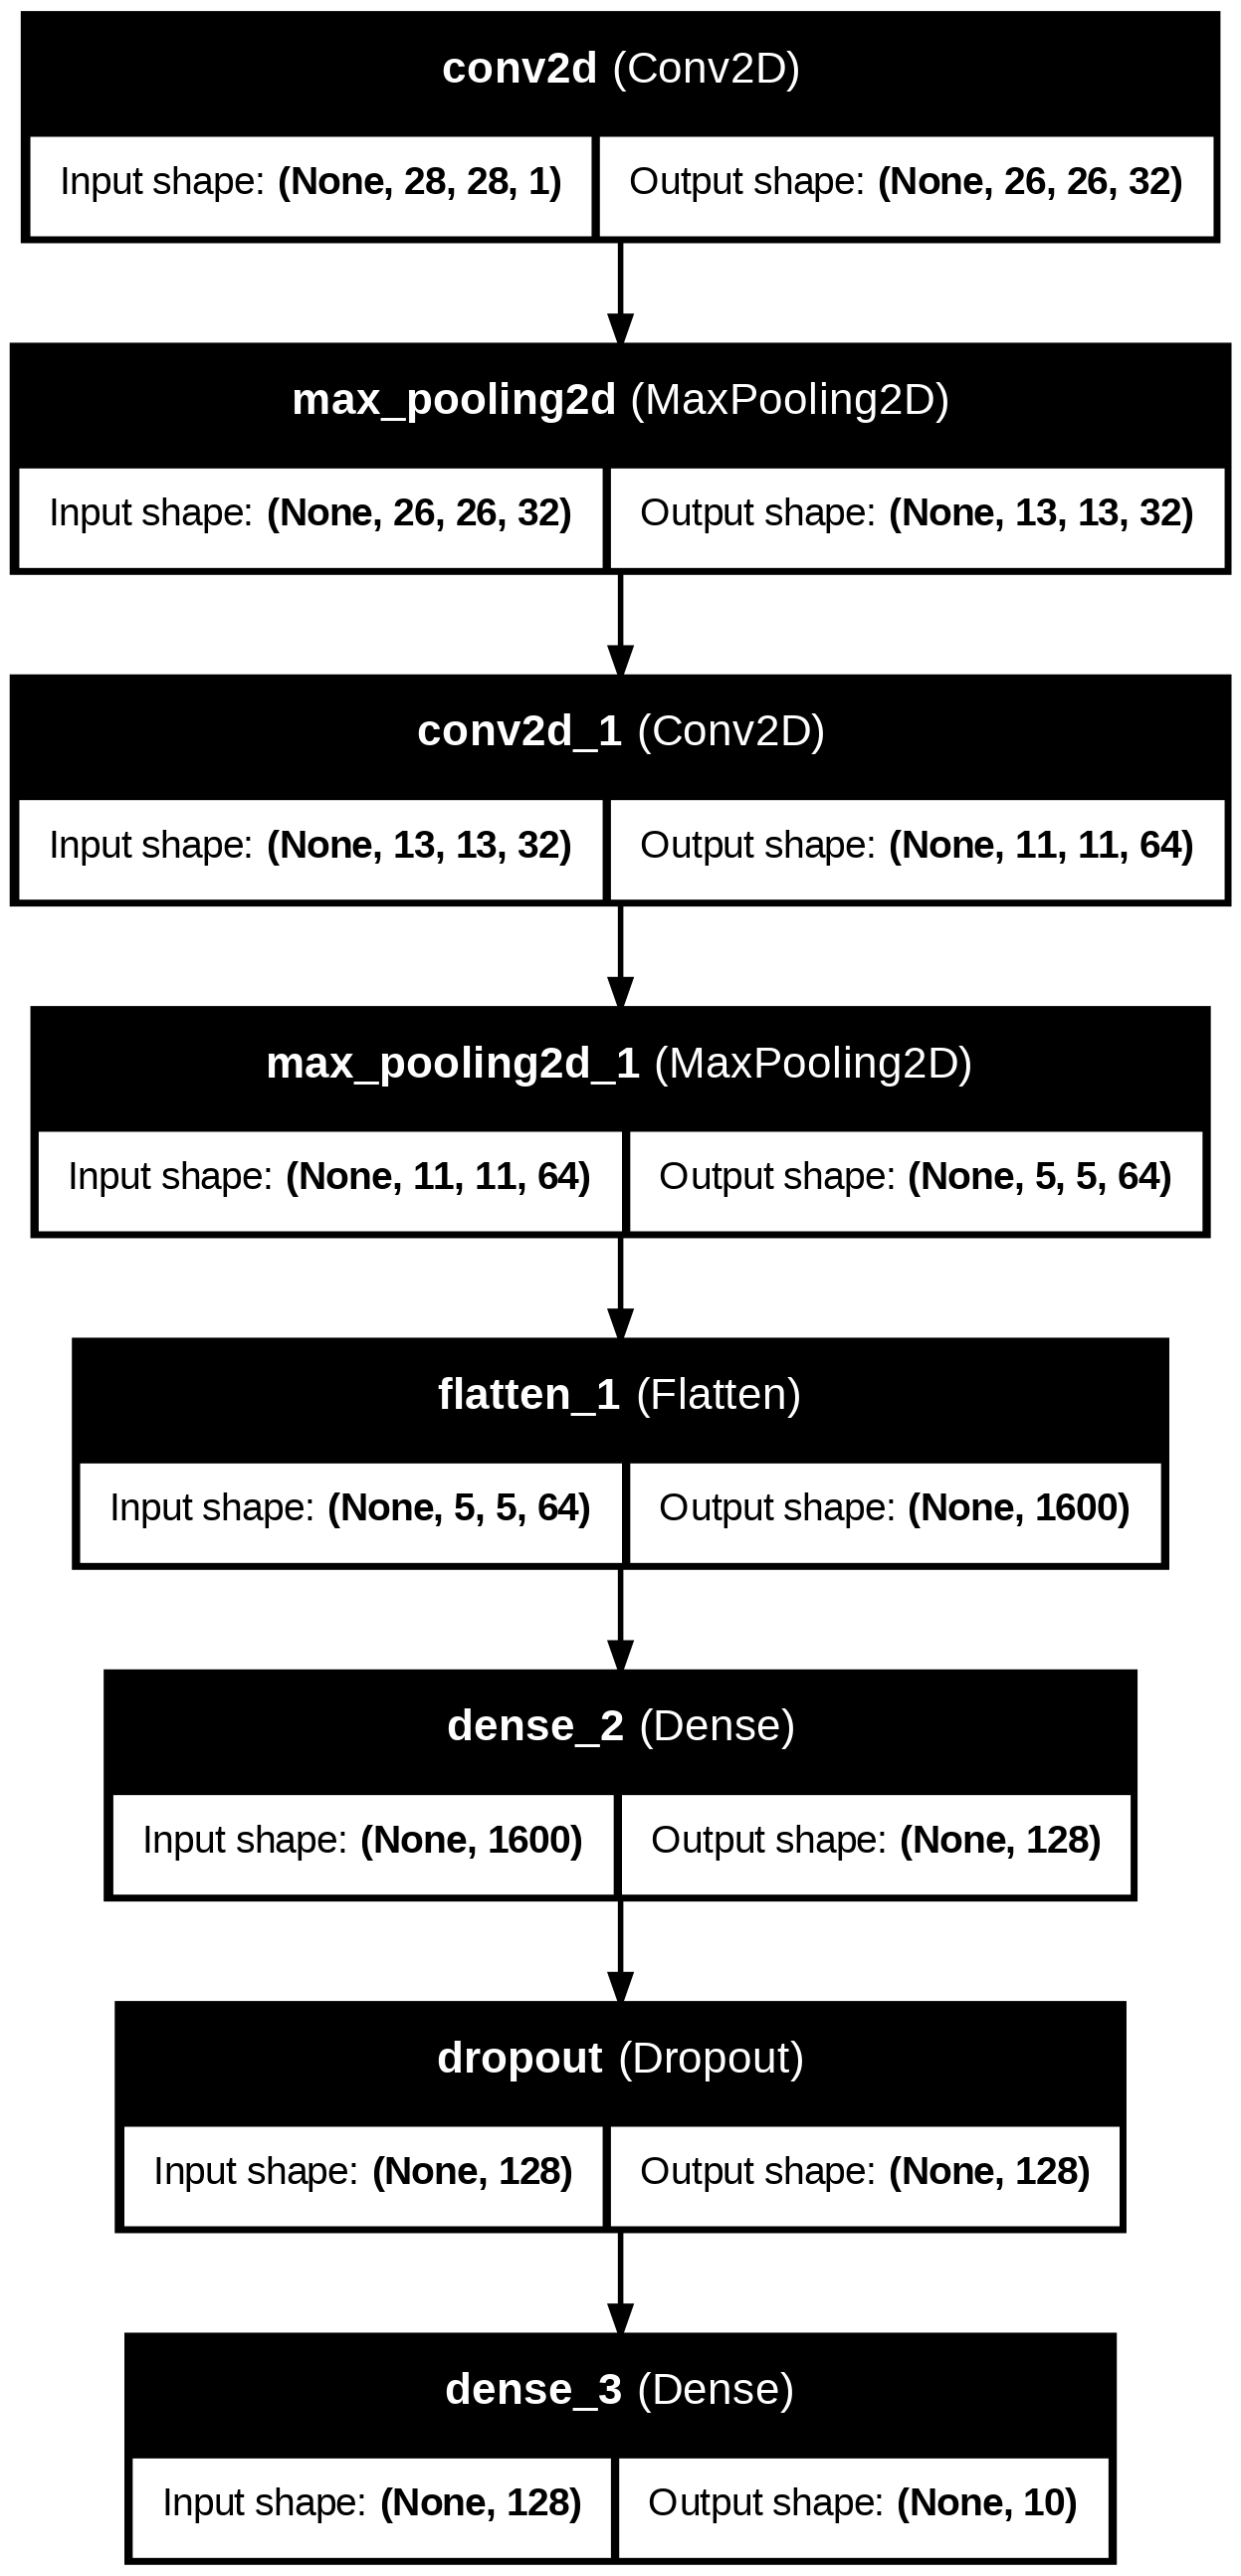

In [ ]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 50, restore_best_weights = True)

In [ ]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs = 1000, batch_size = 32, #potencias de 2 en 32, entre más grande más rapido es con menos precicion
                    validation_data = (X_val, y_val), callbacks = [early_stopping]) #entrena el modelo

Epoch 1/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 58s 35ms/step - accuracy: 0.8501 - loss: 0.4750 - val_accuracy: 0.9805 - val_loss: 0.0634
Epoch 2/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.9733 - loss: 0.0906 - val_accuracy: 0.9877 - val_loss: 0.0434
Epoch 3/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.9818 - loss: 0.0624 - val_accuracy: 0.9891 - val_loss: 0.0348
Epoch 4/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9859 - loss: 0.0463 - val_accuracy: 0.9889 - val_loss: 0.0382
Epoch 5/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.9879 - loss: 0.0401 - val_accuracy: 0.9914 - val_loss: 0.0306
Epoch 6/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9887 - loss: 0.0354 - val_accuracy: 0.9913 - val_loss: 0.0313
Epoch 7/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 84s 34ms/step - accuracy: 0.9900 - loss: 0.0311 - val_accuracy: 0.9905 - val_loss: 0.0348
Epoch 8/1000
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - ac

In [ ]:
score = model.evaluate(X_test, y_test)

329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9897 - loss: 0.0388


In [ ]:
print(f'Accuracy: {score[1]}')
print(f'Loss: {score[0]}')

Accuracy: 0.9910476207733154
Loss: 0.03380756080150604


In [ ]:
history.history.keys()
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

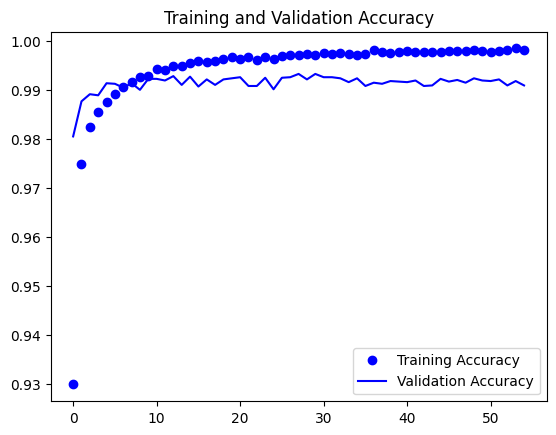

In [ ]:
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, 'bo', label = 'Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

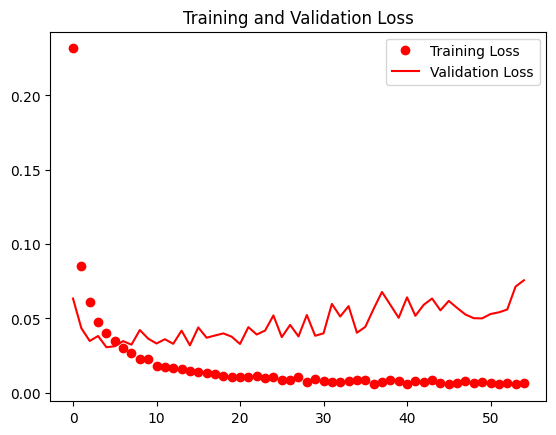

In [ ]:
plt.plot(epochs, loss, 'ro', label = 'Training Loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis = 1)
Y_true = np.argmax(y_test, axis = 1)

329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


<Axes: >

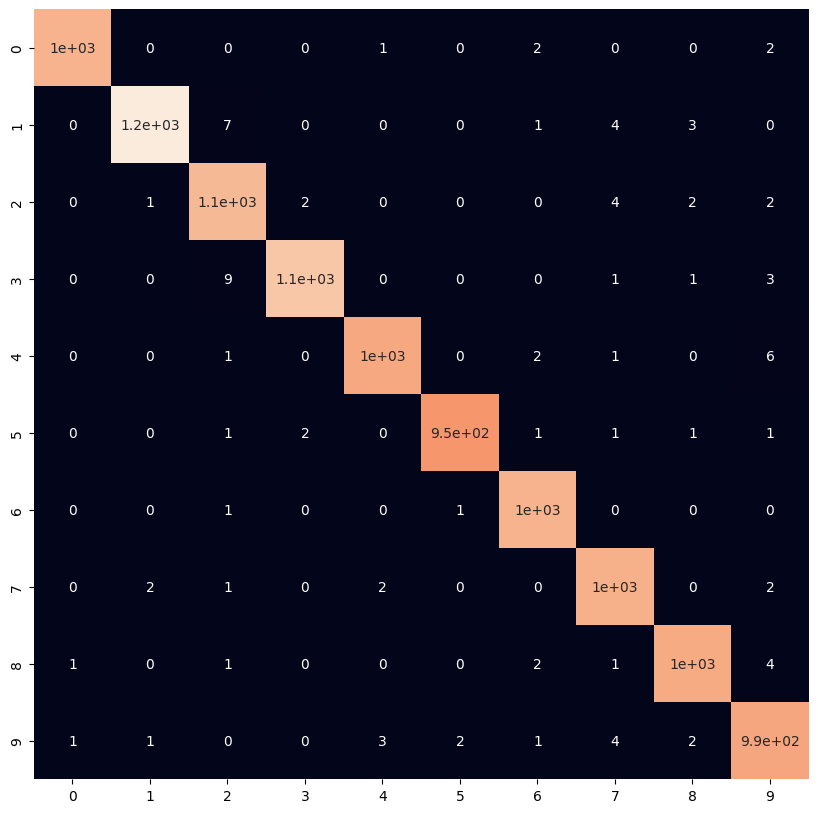

In [ ]:

cm = confusion_matrix(Y_true, y_pred)
plt.figure(figsize = (10, 10))
sns.heatmap(cm, annot = True, cbar = False)

In [ ]:
print(classification_report(Y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1037
           1       1.00      0.99      0.99      1226
           2       0.98      0.99      0.99      1063
           3       1.00      0.99      0.99      1109
           4       0.99      0.99      0.99      1009
           5       1.00      0.99      0.99       957
           6       0.99      1.00      0.99      1035
           7       0.98      0.99      0.99      1036
           8       0.99      0.99      0.99      1020
           9       0.98      0.99      0.98      1008

    accuracy                           0.99     10500
   macro avg       0.99      0.99      0.99     10500
weighted avg       0.99      0.99      0.99     10500



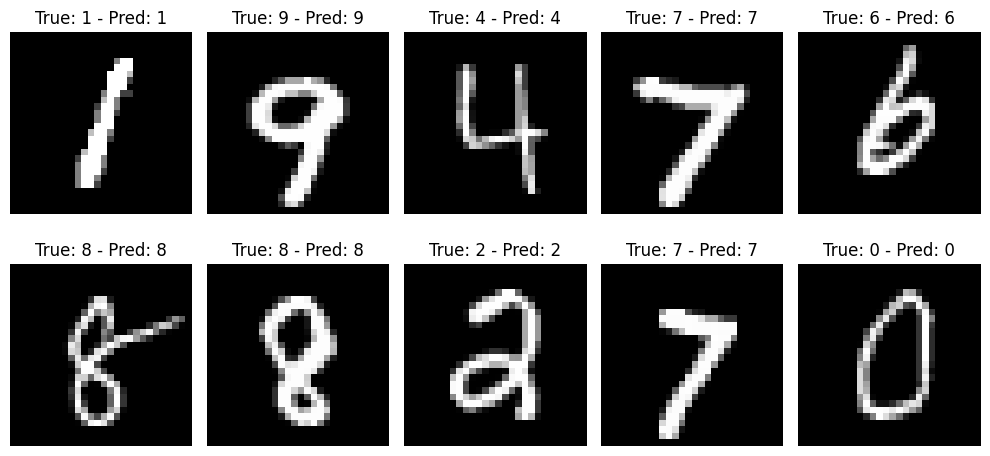

In [ ]:
fig, axs = plt.subplots(2, 5, figsize = (10, 5))
for i in range (10):
  ax = axs[i // 5, i % 5]
  ax.imshow(np.array(X_test[i]).reshape(28, 28), cmap = 'gray')
  ax.set_title(f'True: {Y_true[i]} - Pred: {y_pred[i]}')
  ax.axis('off')
plt.tight_layout()
plt.show()